# Alexander Swartz | as7629

# Environment Summary
All runs used the L4 GPU runtime in google colab (24 GB)

Pytorch version: 2.10.0+cu128

Transformers version: 5.0.0

Datasets version: 4.0.0

# Wandb
I also encounter errors with wand.init hanging. Additionally, fully running this notebook with the L4 google colab runtime will take about 10 hours and google colab timesout, so the runs I logged to wandb were pieced together from different runtimes. The notebook can still be run top to bottom and will populate all results to a new wandb project configured at the beginning.

My runs in wandb are best organized by "group", which correspond to C1, C3, etc. For example, for C3 there are 4 runs for each num_workers plus a run called "C3 Num Workers Comparison Table" which has the table and plot.
A few runs have a status of "crashed" because of errors that occured after training completed as normal but I hadn't called wandb.finish().
I'm not copying screenshots of wandb runs because it's impossible to display all the relevant columns together. In each question I will link to each wandb run that was actually logged to the original project

My wandb project: https://wandb.ai/as7629-columbia-university/hpml-hw2/table

In [82]:
import transformers
import torch
import datasets
print(f"Transformers version: {transformers.__version__}")
print(f"Datasets version: {datasets.__version__}")

Transformers version: 5.0.0
Datasets version: 4.0.0


# Imports

In [77]:
import wandb
import os
from torch.utils.data import DataLoader
from transformers import DistilBertTokenizerFast, DataCollatorWithPadding
import torch
from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast
from datasets import load_dataset
from torch.profiler import profile, ProfilerActivity, schedule, tensorboard_trace_handler
import torch.nn as nn
import numpy as np
import time
from google.colab import userdata


# Wandb Setup and Baseline Config

In [19]:
entity = "as7629-columbia-university"
project_name = "hpml-hw2"
os.environ["WANDB_API_KEY"] = userdata.get('WANDB_API_KEY')
wandb.init(project=project_name, group="C1")
wandb.run.name = "nw2_bs32_lr1e-4_epoch5_adamw_nocompile_baseline"
baseline_config = {
    "model_name": "distilbert-base-uncased",
    "max_len": 256,
    "batch_size": 32,
    "lr": 1e-4,
    "optimizer": "AdamW",
    "num_workers": 2,
    "epochs": 2,
    "compile_mode": False,
    "profiler": True
}
wandb.config.update(baseline_config)
config = wandb.config

In [11]:
dataset = load_dataset("imdb")

# Utility functions

In [12]:
def accuracy_from_logits(logits, labels):
    preds = torch.argmax(logits, dim=-1)
    correct = (preds == labels).sum().item()
    total = labels.numel()
    return correct, total

In [13]:
def write_df_to_wandb_table(df, table_name, group):
    os.environ["WANDB_API_KEY"] = userdata.get('WANDB_API_KEY')

    wandb.init(project=project_name, group=group)

    table = wandb.Table(dataframe=df)
    wandb.run.name = table_name
    wandb.log({table_name: table})

# IMDBTrainer Class

In [57]:
class IMDBTrainer:
    def __init__(self, config):
        self.config = config
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self._build_data()
        self._build_model()
        self._build_optimizer()
        self.loss_fn = nn.CrossEntropyLoss()
        if self.config.profiler:
            self._build_profiler()


    def _build_data(self):
        dataset = load_dataset("imdb")
        tokenizer = DistilBertTokenizerFast.from_pretrained(wandb.config.model_name)

        def tokenize(batch):
            return tokenizer(batch["text"], truncation=True, max_length=wandb.config.max_len)

        tokenized_train = dataset["train"].map(tokenize, batched=True, remove_columns=["text"])
        tokenized_test  = dataset["test"].map(tokenize, batched=True, remove_columns=["text"])

        # optionally reduce training and eval size
        # tokenized_train = tokenized_train.train_test_split(test_size=0.999, seed=42)['train']
        # tokenized_test = tokenized_test.train_test_split(test_size=0.999, seed=42)['train']

        # sets max length of padding to max length of each batch
        data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

        tokenized_train = tokenized_train.rename_column("label", "labels")
        tokenized_test = tokenized_test.rename_column("label", "labels")
        tokenized_train.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
        tokenized_test.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

        collate_fn = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")

        self.train_loader = DataLoader(
            tokenized_train,
            batch_size=wandb.config.batch_size,
            shuffle=True,
            num_workers=wandb.config.num_workers,
            pin_memory=self.device.type == "cuda",
            collate_fn=collate_fn
        )

        self.test_loader = DataLoader(
            tokenized_test,
            batch_size=wandb.config.batch_size,
            shuffle=False,
            num_workers=wandb.config.num_workers,
            pin_memory=self.device.type == "cuda",
            collate_fn=collate_fn
        )

    def _build_model(self):
        self.model = DistilBertForSequenceClassification.from_pretrained(
            self.config.model_name,
            num_labels=2
        )

        self.model.to(self.device)

        if self.config.compile_mode:
            self.model = torch.compile(self.model, backend="inductor")

    def _build_optimizer(self):
        if self.config.optimizer == "AdamW":
            self.optimizer = torch.optim.AdamW(
                self.model.parameters(),
                lr=self.config.lr
            )
        elif self.config.optimizer == "Adam":
            self.optimizer = torch.optim.Adam(
                self.model.parameters(),
                lr=self.config.lr
            )
        elif self.config.optimizer == "SGD":
            self.optimizer = torch.optim.SGD(
                self.model.parameters(),
                lr=self.config.lr
            )
        else:
            raise ValueError("Unknown optimizer")

    def _build_profiler(self):
        self.logdir = f'./tensorboard_logdir'
        self.activities = [ProfilerActivity.CPU]
        if self.device.type == "cuda":
            self.activities.append(ProfilerActivity.CUDA)

        self.prof_sched = schedule(
            wait=0,
            warmup=1, # set profiler active but don't record first batch
            active=50, # record batches 2-201
            repeat=1
        )

    def _train_one_epoch(self, prof=None):
        self.model.train()
        data_time = 0
        compute_time = 0
        epoch_loss = 0.0
        correct = 0
        total = 0
        start_t = time.time()
        data_load_start_time = start_t

        for step, batch in enumerate(self.train_loader, start=1):
            input_ids = batch["input_ids"].to(self.device, non_blocking=True)
            attention_mask = batch["attention_mask"].to(self.device, non_blocking=True)
            labels = batch["labels"].to(self.device, non_blocking=True)
            if self.device.type == "cuda":
                torch.cuda.synchronize()
            data_time += time.time() - data_load_start_time

            self.optimizer.zero_grad(set_to_none=True)

            compute_start_time = time.time()
            outputs = self.model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss # average loss in batch
            logits = outputs.logits

            loss.backward()
            self.optimizer.step()
            if self.device.type == "cuda":
                torch.cuda.synchronize()
            compute_time += time.time() - compute_start_time

            batch_size = labels.size(0)
            epoch_loss += loss.item() * batch_size # add sum of losses in batch to total
            c, n = accuracy_from_logits(logits, labels)
            correct += c
            total += n

            # if (step % 50 == 0):
            #     elapsed = time.time() - start_t
            #     print(
            #         f"  step {step:5d}/{len(self.train_loader)} "
            #         f"loss {(epoch_loss/total):.4f} acc {(correct/total):.4f} "
            #         f"time {elapsed:.1f}s"
            #     )

            if prof:
                prof.step()
            data_load_start_time = time.time()

        return (epoch_loss / total), (correct / total), data_time, compute_time

    @torch.no_grad()
    def evaluate(self):
        self.model.eval()
        correct = 0
        total = 0

        for batch in self.test_loader:
            input_ids = batch["input_ids"].to(self.device, non_blocking=True)
            attention_mask = batch["attention_mask"].to(self.device, non_blocking=True)
            labels = batch["labels"].to(self.device, non_blocking=True)

            outputs = self.model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            logits = outputs.logits
            c, n = accuracy_from_logits(logits, labels)
            correct += c
            total += n

        return correct / total

    def train_pipeline(self):
          import time
          total_data_time = 0
          total_epoch_time = 0
          total_compute_time = 0
          epoch_6_10_times = []

          for epoch in range(1, wandb.config.epochs + 1):
              epoch_time_start = time.time()
              if self.config.profiler and epoch == 1:
                  with profile(
                      activities=self.activities,
                      schedule=self.prof_sched,
                      on_trace_ready=tensorboard_trace_handler(
                          self.logdir,
                          worker_name=f'num_workers={self.config.num_workers}'
                      ),
                      record_shapes=True,
                      profile_memory=True,
                  ) as prof:
                      train_loss, train_acc, data_time, compute_time = self._train_one_epoch(prof)
              else:
                  train_loss, train_acc, data_time, compute_time = self._train_one_epoch()

              test_acc = self.evaluate()

              epoch_time = time.time() - epoch_time_start
              total_data_time += data_time
              total_epoch_time += epoch_time
              total_compute_time += compute_time

              if epoch == 1:
                  wandb.summary["time/first_epoch"] = epoch_time

              if 6 <= epoch <= 10:
                  epoch_6_10_times.append(epoch_time)

              # print(
              #     f"Epoch {epoch:02d} | "
              #     f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
              #     f"acc {test_acc:.4f} | "
              #     f"time {epoch_time:.1f}s"
              # )

              wandb.log({
                  "train/loss": train_loss,
                  "train/acc": train_acc,
                  "test/acc": test_acc,
                  "time/data_loading": data_time,
                  "time/compute": compute_time,
                  "time/epoch": epoch_time,
              }, step=epoch)

          avg_epoch_time = total_epoch_time / wandb.config.epochs
          if epoch_6_10_times:
              wandb.summary["time/avg_epoch_6_10_time"] = sum(epoch_6_10_times) / 5
          wandb.summary["time/total_data_time"] = total_data_time
          wandb.summary["time/avg_epoch_time"] = avg_epoch_time
          wandb.summary["time/total_compute_time"] = total_compute_time
          wandb.summary["time/total_train_time"] = total_epoch_time
          wandb.summary["train/final_train_acc"] = train_acc
          wandb.summary["train/final_train_loss"] = train_loss
          wandb.summary["test/final_test_acc"] = test_acc

# C1 and C2 Fine-tuning a Small LLM and Baseline Timing

In [74]:
trainer = IMDBTrainer(config)
trainer.train_pipeline()
wandb.finish()

In [21]:
api = wandb.Api()
runs = api.runs(f"{entity}/{project_name}")
df_c3_rows = []
for run in runs:
    if run.group == "C1":
        history = run.history(keys=[
            "time/data_loading", "time/compute", "time/epoch", "train/acc", "train/loss"])
        print("Training loss:", [f"{x:.3f}" for x in history["train/loss"].tolist()])
        print("Training accuracy:", [f"{x:.3f}" for x in history["train/acc"].tolist()])
        print("Data loading time (s):", [f"{x:.3f}" for x in history["time/data_loading"].tolist()])
        print("Training computation times (s): ", [f"{x:.3f}" for x in history["time/compute"].tolist()])
        print("Total epoch training time (s): ", [f"{x:.3f}" for x in history["time/epoch"].tolist()])


Training loss: ['0.424', '0.209', '0.104', '0.047', '0.069']
Training accuracy: ['0.800', '0.924', '0.966', '0.986', '0.977']
Data loading time (s): ['0.157', '0.127', '0.115', '0.115', '0.116']
Training computation times (s):  ['12.041', '11.019', '11.023', '11.013', '10.996']
Total epoch training time (s):  ['20.470', '14.950', '14.929', '14.919', '14.932']
Training loss: ['0.474', '0.231', '0.107', '0.060', '0.058']
Training accuracy: ['0.764', '0.905', '0.961', '0.981', '0.978']
Data loading time (s): ['0.133', '0.120', '0.119', '0.122', '0.119']
Training computation times (s):  ['23.259', '22.839', '23.363', '23.913', '24.053']
Total epoch training time (s):  ['36.165', '31.397', '32.231', '33.048', '33.065']


Wandb run: https://wandb.ai/as7629-columbia-university/hpml-hw2/runs/14jbeidg

# C3 DataLoader Performance

In [73]:
for num_workers in [0, 2, 4, 8]:
    wandb.init(
        project=project_name,
        config={**baseline_config, "num_workers": num_workers},
        name=f"nw{num_workers}_bs32_lr1e-4_epoch2_adamw_nocompile",
        group="C3"
    )

    config = wandb.config

    trainer = IMDBTrainer(config)
    trainer.train_pipeline()
    wandb.finish()

In [31]:
api = wandb.Api()
runs = api.runs(f"{entity}/{project_name}")
df_c3_rows = []
for run in runs:
    if run.group == "C3" and "Table" not in run.name:
        df_c3_rows.append({
            "time/avg_epoch_time": run.summary.get("time/avg_epoch_time"),
            "time/total_data_time": run.summary.get("time/total_data_time"),
            "num_workers": run.config.get("num_workers")
        })

df_c3 = pd.DataFrame(df_c3_rows).sort_values(["num_workers"])
df_c3

,time/avg_epoch_time,time/total_data_time,num_workers
3,342.789072,35.429120,0
2,318.657115,2.443788,2
1,318.779687,2.575410,4
0,318.899423,3.058376,8


In [75]:
write_df_to_wandb_table(df_c3, "C3 Num Workers Comparison Table", "C3")

Logging plot to C3 Num Workers Comparison Table in Wandb


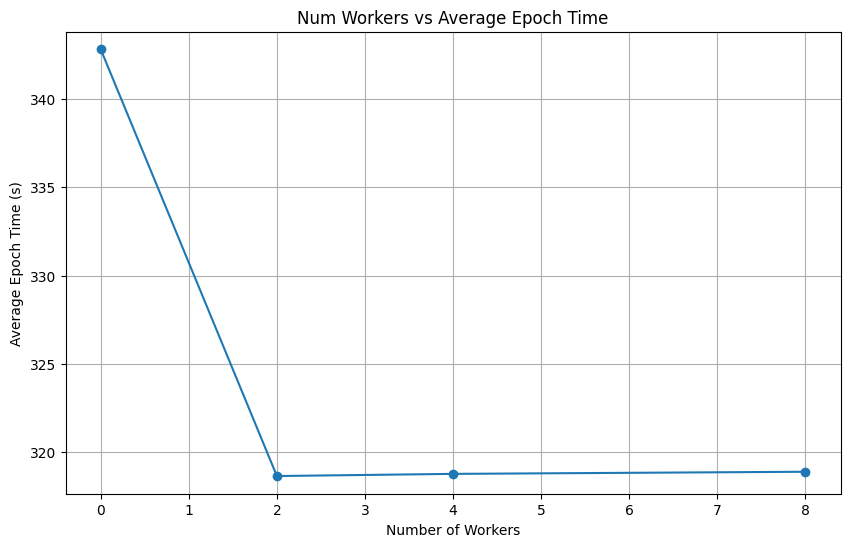

In [30]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df_c3['num_workers'], df_c3['time/avg_epoch_time'], marker='o', linestyle='-')
ax.set_title('Num Workers vs Average Epoch Time')
ax.set_xlabel('Number of Workers')
ax.set_ylabel('Average Epoch Time (s)')

# used custom y-axis, otherwise scale is off
ax.set_ylim(min(df_c3['time/avg_epoch_time']) - 1, max(df_c3['time/avg_epoch_time']) + 1)
ax.grid(True)

wandb.log({"Num Workers vs Average Epoch Time": wandb.Image(fig)})
print("Logging plot to C3 Num Workers Comparison Table in Wandb")
plt.show()
wandb.finish()

Wandb runs:
- https://wandb.ai/as7629-columbia-university/hpml-hw2/runs/dxm6ygqn
- https://wandb.ai/as7629-columbia-university/hpml-hw2/runs/izeue54e
- https://wandb.ai/as7629-columbia-university/hpml-hw2/runs/x69dhwuj
- https://wandb.ai/as7629-columbia-university/hpml-hw2/runs/wg47j6qm

Above table and plot are logged to wandb here: https://wandb.ai/as7629-columbia-university/hpml-hw2/runs/14csucvv

Analysis: The optimal num_workers (nw) was 2, although nw=4 and nw=8 were both within a second as fast when measured by average epoch training time. nw=0 was substantially slower (24.131 s) slower than nw=2. This slowdown corresponds to the increase in total data loading time from 2.448 s to 35.429 s when moving from nw=2 to nw=0. This is because nw=0 means there are no parallel CPU processes to support data prefetching and overlap. Increasing nw beyond 2 does not decrease data loading time or training because the prefetching pipeline is already saturating, additional workers add more time in overhead than they can save.

The calls to torch.cuda.sychronized() in the training loop can also limit prefetching due to CPU waiting for GPU. Removing these calls could provide clearer information about the strength of increasing nw.

# C4 PyTorch Profiler

In [72]:
# since my optimal num_workers was 2, I decided to include num_workers=8 for extra data
for num_workers in [1, 2, 8]:
    wandb.init(
        project=project_name,
        config={**baseline_config, "num_workers": num_workers, "profiler": True},
        name=f"nw{num_workers}_bs32_lr1e-4_epoch5_adamw_nocompile_profile",
        group="C4"
    )

    config = wandb.config

    trainer = IMDBTrainer(config)
    trainer.train_pipeline()
    wandb.finish()

Wandb runs:
- https://wandb.ai/as7629-columbia-university/hpml-hw2/runs/ux6xjzim
- https://wandb.ai/as7629-columbia-university/hpml-hw2/runs/k514673f
- https://wandb.ai/as7629-columbia-university/hpml-hw2/runs/8g437t62

Commands for displaying Tensorboard are after C7 because having Tensorboard up was causing wandb.init to hang. The following are screenshots and analysis of the original tensorboard runs which use the same configuration as above. Since my optimal num_workers was 2, I decided to include num_workers=8 for extra data.

Tensorboard overview for default config and num_workers=1
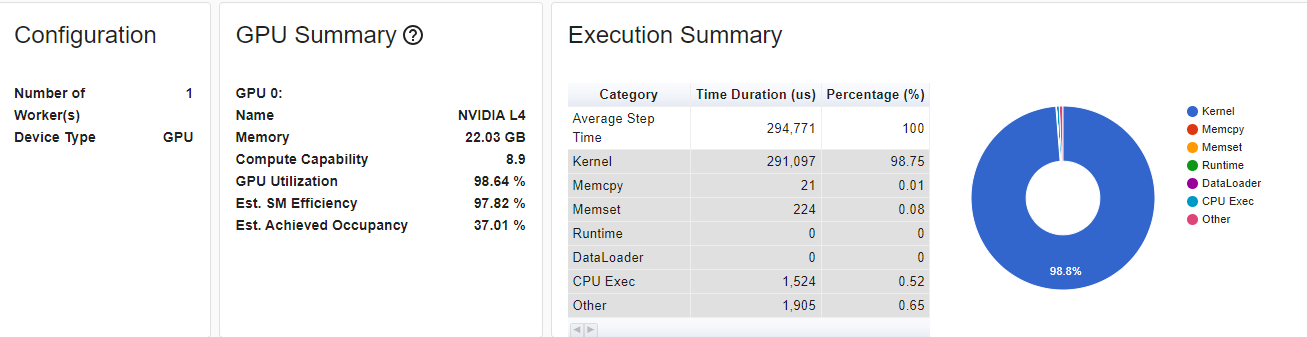

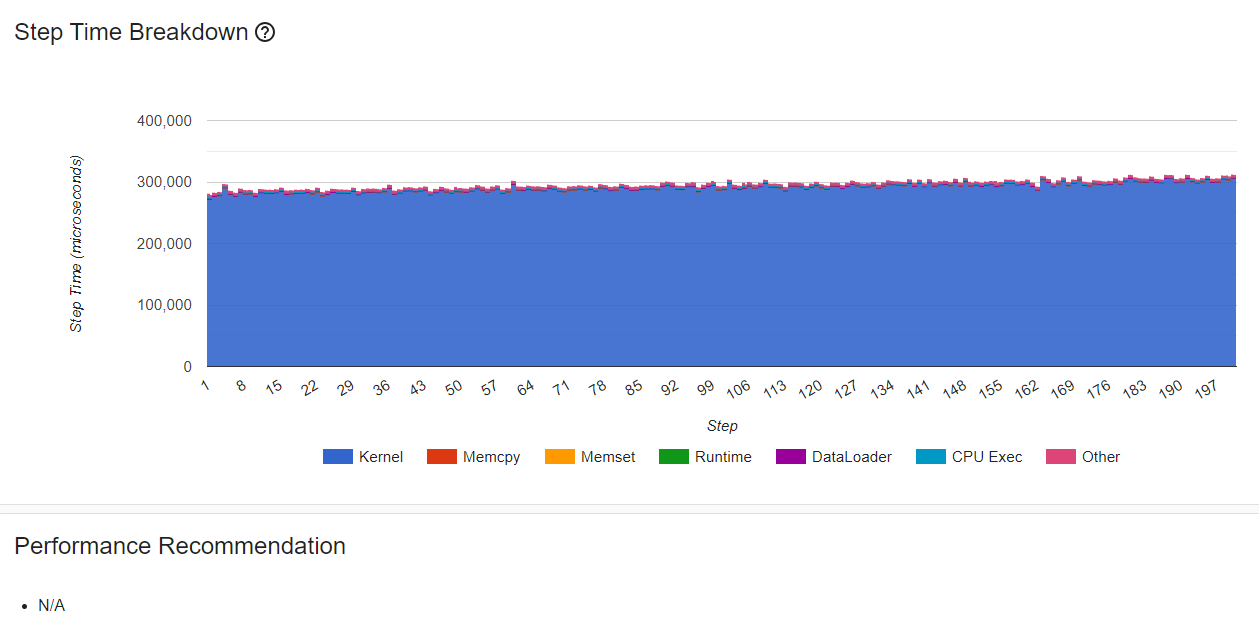

Tensorboard overview for default config and num_workers=2

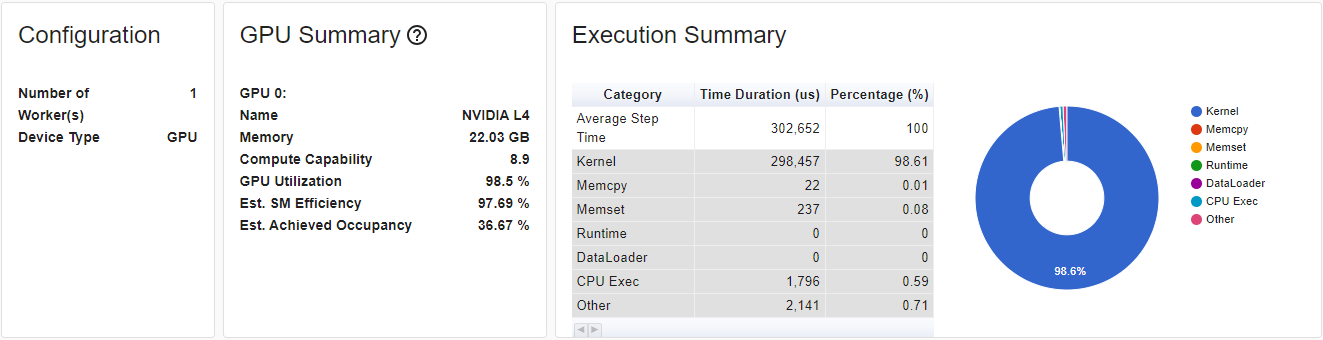

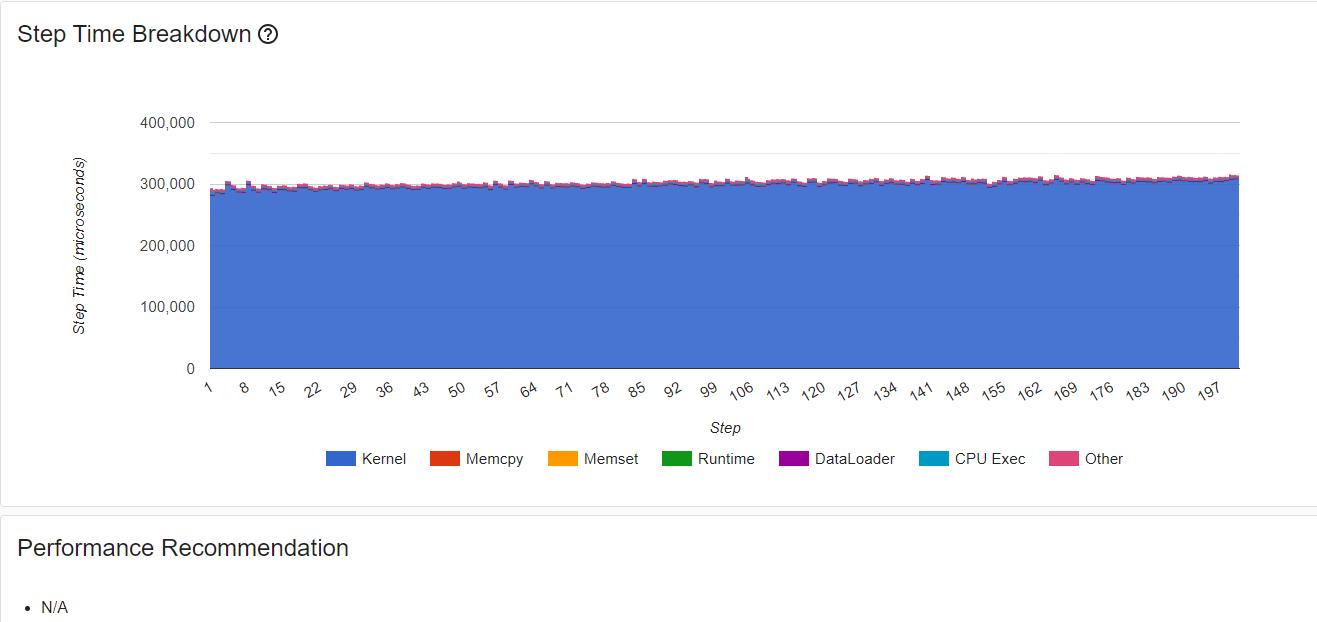

Tensorboard overview for default config and num_workers=8

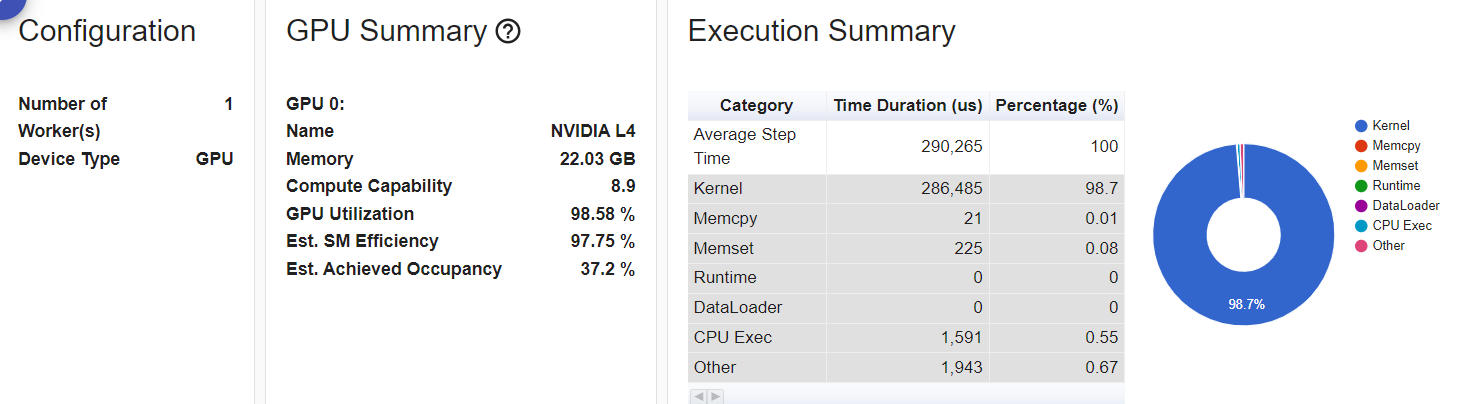

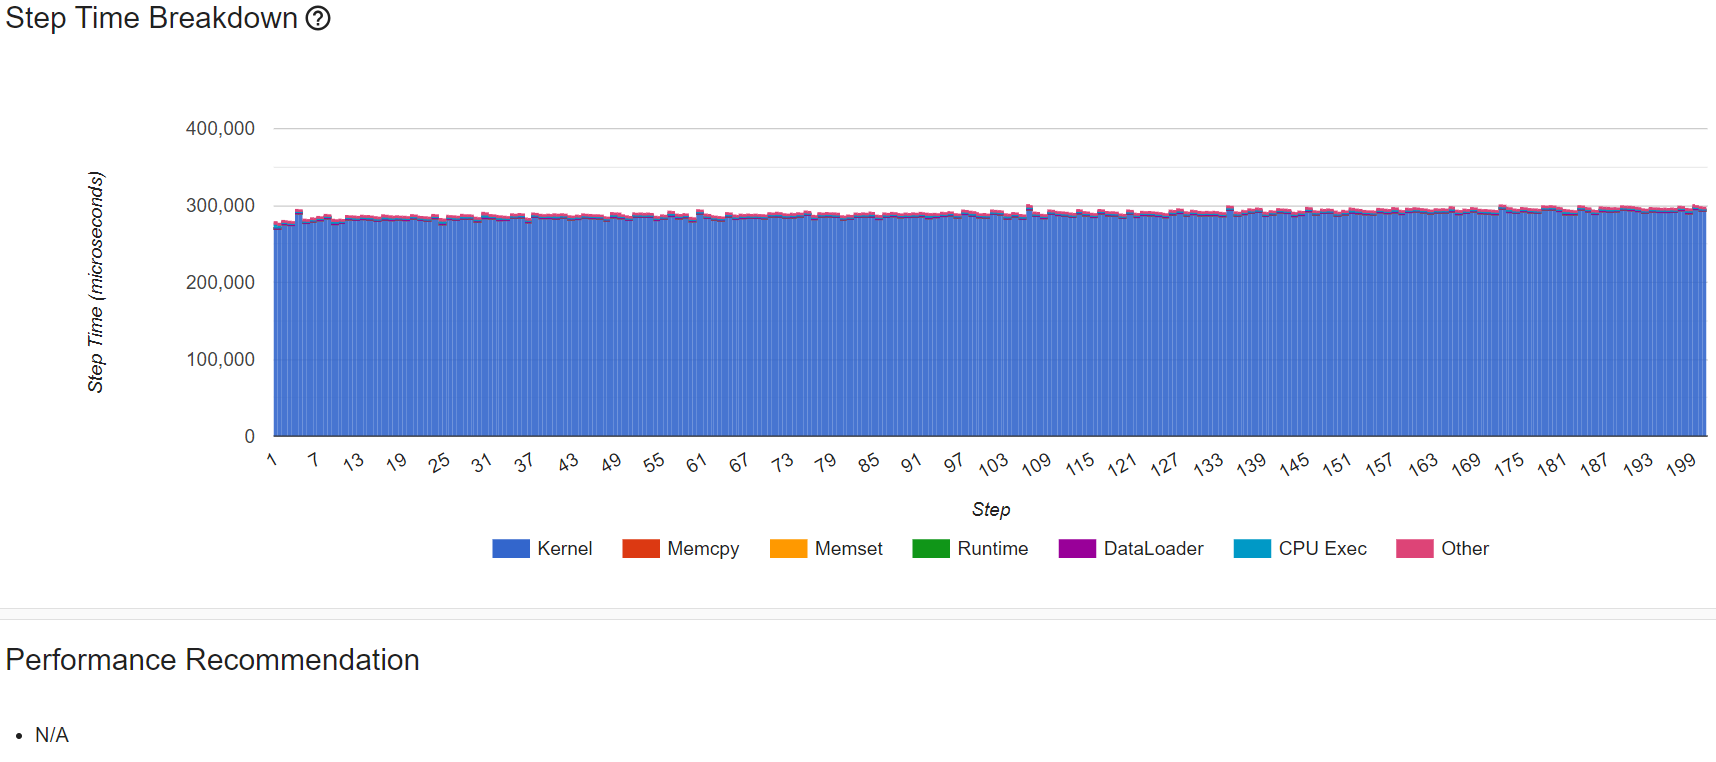

As another student pointed out on Ed, when nw>0, the data loading is being done in separate processes than the main thread. It appears that my profiler only captured the main thread, which is why it doesn't account for the data loading computations like collation and padding. Additionally, the DistiliBERT model is so large that training is GPU bound, meaning there is plenty of time to load data during GPU computations. Since less than 2% of the time is spent on CPU and memcpy, increasing num_workers did not have a noticable affect.

The profiler identified that this training loop is extremely GPU-bound. Although Tensorboard did not give explicit performance recommendations, increasing the number of tensorcores and bandwidth would provide the largest performance improvements. Although I did not save the data, this was shown when I tested running with the A100, which has an average epoch time roughly half of with the L4.

# C5 Hyperparameter Sensitivity Table

In [71]:
for batch_size in [16, 32, 64]:
    for lr in [5e-5, 1e-4, 5e-4]:
        wandb.init(
            project=project_name,
            config={**baseline_config, "batch_size": batch_size, "lr": lr},
            name=f"nw32_bs{batch_size}_lr{lr}_epoch5_adamw_nocompile",
            group="C5"
        )

        config = wandb.config

        trainer = IMDBTrainer(config)
        trainer.train_pipeline()
        wandb.finish()

In [35]:
api = wandb.Api()
runs = api.runs(f"{entity}/{project_name}")
df_c5_rows = []
for run in runs:
    if run.group == "C5" and "Table" not in run.name:
        df_c5_rows.append({
            "train/final_train_acc": run.summary.get("train/final_train_acc"),
            "train/final_train_loss": run.summary.get("train/final_train_loss"),
            "test/final_test_acc": run.summary.get("test/final_test_acc"),
            "time/total_train_time": run.summary.get("time/total_train_time"),
            "lr": run.config.get("lr"),
            "batch_size": run.config.get("batch_size")
        })
df_c5 = pd.DataFrame(df_c5_rows).sort_values(["batch_size", "lr"])

In [36]:
df_c5

,train/final_train_acc,train/final_train_loss,test/final_test_acc,time/total_train_time,lr,batch_size
0,0.98868,0.036930,0.87596,1667.249879,0.00005,16
1,0.96932,0.103452,0.83472,1664.426698,0.00010,16
2,0.49448,0.697089,0.50000,1619.638223,0.00050,16
3,0.87028,0.297581,0.90624,1635.706956,0.00005,32
4,0.85992,0.323166,0.89780,1633.456004,0.00010,32
5,0.49628,0.693269,0.50000,1611.088781,0.00050,32
6,0.98324,0.049228,0.90104,1490.683963,0.00005,64
7,0.87408,0.297275,0.90632,1495.821067,0.00010,64
8,0.49684,0.693814,0.50000,1476.524896,0.00050,64


In [69]:
write_df_to_wandb_table(df_c5, "C5 Hyperparameter Sensitivity Table", "C5")
wandb.finish()

Wanbd runs:
- https://wandb.ai/as7629-columbia-university/hpml-hw2/runs/xx11iisy
- https://wandb.ai/as7629-columbia-university/hpml-hw2/runs/rb1k39hq
- https://wandb.ai/as7629-columbia-university/hpml-hw2/runs/opo9nn3q
- https://wandb.ai/as7629-columbia-university/hpml-hw2/runs/o2gf95rc
- https://wandb.ai/as7629-columbia-university/hpml-hw2/runs/jd8ne6kf
- https://wandb.ai/as7629-columbia-university/hpml-hw2/runs/dhzfv9rn
- https://wandb.ai/as7629-columbia-university/hpml-hw2/runs/5ph508q2
- https://wandb.ai/as7629-columbia-university/hpml-hw2/runs/4jwudc3n
- https://wandb.ai/as7629-columbia-university/hpml-hw2/runs/1lsrbfsa

Above table logged to wandb and available at https://wandb.ai/as7629-columbia-university/hpml-hw2/runs/9los8tqn

Analysis:

Moving from batch_size=16 to batch_size=64 resulted in a 10.6% reduction in training time due to the larger batches allowing for better GPU parallelization. Oftentimes, larger batch_size values reduce generalizability because they can lead the weights to a unstable, sharp minimum. However, these results don't show that a larger batch_size reduces generazability because the final test accuracy between batch_sizes 32 and 64 were all between .89 and .91 (excluding lr=5e-4, which failed to converge).

Increase learning ran can sometimes increase the speed of convergence. However, it also create instability as the weights get updated more aggressively. This was illustrated by all 3 models with lr=5e-4, which stayed very close to .5 train accuracy throughout all of training. This failure to converge suggests the optimizer keeps overshooting the direction of the minimum cost in weight space. Since the smaller learning rates converge and achieve final test accuracies above .8, the optimal lr is definitely lower than 5e-4. lr=1e-5 had an average test accuracy across the 3 batch_size values of .894, while lr=1e-4 had an average test accuracy of .880, suggesting very little difference between the two.

# C6 Optimizer Comparison

In [67]:
for optimizer in ["SGD", "Adam", "AdamW"]:
    wandb.init(
        project=project_name,
        config={**baseline_config, "optimizer": optimizer},
        name=f"nw2_bs32_lr1e-4_epoch5_{optimizer}_nocompile",
        group="C6"
    )

    config = wandb.config

    trainer = IMDBTrainer(config)
    trainer.train_pipeline()
    wandb.finish()

In [17]:
api = wandb.Api()
runs = api.runs(f"{entity}/{project_name}")
df_c6_rows = []
for run in runs:
    if run.group == "C6" and "Table" not in run.name:
        df_c6_rows.append({
            "train/final_train_acc": run.summary.get("train/final_train_acc"),
            "train/final_train_loss": run.summary.get("train/final_train_loss"),
            "test/final_test_acc": run.summary.get("test/final_test_acc"),
            "time/avg_epoch_time": run.summary.get("time/avg_epoch_time"),
            "optimizer": run.config.get("optimizer")
        })
df_c6 = pd.DataFrame(df_c6_rows).sort_values(["optimizer"])
df_c6

nw2_bs32_lr1e-4_epoch5_SGD_nocompile
nw2_bs32_lr1e-4_epoch5_Adam_nocompile
nw2_bs32_lr1e-4_epoch5_AdamW_nocompile


,train/final_train_acc,train/final_train_loss,test/final_test_acc,time/avg_epoch_time,optimizer
1,0.9184,0.221466,0.8500,34.726946,Adam
2,0.9112,0.231796,0.8628,35.505639,AdamW
0,0.5124,0.692368,0.5188,31.774428,SGD


In [68]:
write_df_to_wandb_table(df_c6, "C6 Optimizer Comparison Table", "C6")
wandb.finish()

Wandb runs:
- https://wandb.ai/as7629-columbia-university/hpml-hw2/runs/o9mv10zq
- https://wandb.ai/as7629-columbia-university/hpml-hw2/runs/5764wfyf

Table: https://wandb.ai/as7629-columbia-university/hpml-hw2/runs/9efj8uac

Analysis:
AdamW and Adam both achieved very similar train accuracies (0.9112 and 0.9184) and test accuracies (0.8628 and 0.8500). In addition to greater final train and test accuracies than SGD, Adam also achieved of train accuracy of .862 after the first epoch, whereas the SGD model was only at .512. This is likely due to Adam accelerating the weights updates in the correct direction because they are not changing too much at the beginning.

The SGD model had a slightly faster average epoch training time (31.774 s compared to 35.505 s and 34.726 s) because it does not have to keep track of the moments of the moving average and squared gradients like Adam does, so there are fewer params to update and store. However, it failed to converge, shown by its training and test accuracies never exceeding .520. This concurrs with the standard practice of using a more advanced optimizer like Adam when the model architecture is complex and will require navigating a complex loss landscape.


# C7 torch.compile Comparison

In [70]:
for compile_mode in [True, False]:
    compile_str = "compile" if compile_mode else "nocompile"
    wandb.init(
        project=project_name,
        config={**baseline_config, "compile_mode": compile_mode, "epochs": 10},
        name=f"nw2_bs32_lr1e-4_epoch10_adamw_{compile_str}",
        group="C7"
    )

    config = wandb.config

    trainer = IMDBTrainer(config)
    trainer.train_pipeline()
    wandb.finish()

In [65]:
api = wandb.Api()
runs = api.runs(f"{entity}/{project_name}")
df_c7_rows = []
for run in runs:
    if run.group == "C7" and "Table" not in run.name:
        if run.config.get("compile_mode"):
            compile_mode_name = "Compile (Inductor)"
        else:
            compile_mode_name = "Eager"
        df_c7_rows.append({
            "time/first_epoch": run.summary.get("time/first_epoch"),
            "time/avg_epoch_6_10_time": run.summary.get("time/avg_epoch_6_10_time"),
            "compile_mode": compile_mode_name
        })
df_c7 = pd.DataFrame(df_c7_rows).sort_values(["compile_mode"])
df_c7

,time/first_epoch,time/avg_epoch_6_10_time,compile_mode
1,364.573421,312.423673,Compile (Inductor)
0,318.603822,318.986973,Eager


In [66]:
write_df_to_wandb_table(df_c7, "C7 torch.compile Comparison Table", "C7")
wandb.finish()

Wandb runs:
- https://wandb.ai/as7629-columbia-university/hpml-hw2/runs/pvogjp4z
- https://wandb.ai/as7629-columbia-university/hpml-hw2/runs/j92d4d4v

Table: https://wandb.ai/as7629-columbia-university/hpml-hw2/runs/ol9pystl

Analysis:
Using torch.compile resulted in a 2% speedup of average epoch training time for epochs 6-10. It also demonstrated the expected warm-up, where the first epoch was slower when it is compiled compared to in eager mode. This is explained in C5.

There were print statements in my training loop during the runs that I collected data for, although they have since been removed. These prints could have causes graph breaks, since they occur on the host and require copying data from gpu to cpu and then restart the GPU graph. Additionally, calling torch.cuda.synchronize() causes the compiler to wait for the GPU to finish its tasks, reducing the compiler's ability to fuse operations is separated by the synchronized calls. Resolving both of these could have decreased graph breaks and allowed torch.compile to achieve greater throughput than shown.

# Display Tensorboard

In [ ]:
# leftover tensorboard processes contributing to wandb.init hanging?
# !pkill -f tensorboard

!pip install torch_tb_profiler
!pip install -U tensorboard-plugin-profile

%reload_ext tensorboard
%tensorboard --logdir tensorboard_logdir

#Q1
Input dimension to DistilBERT’s embedding layer is 768. Found from `print(model)`, which shows `(word_embeddings): Embedding(30522, 768, padding_idx=0)`

In [ ]:
trainer = IMDBTrainer(config)

In [42]:
trainer.model = DistilBertForSequenceClassification.from_pretrained(
      config.model_name,
      num_labels=2
)
print(model)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


#Q2
The output dimension for the classifier head of this model is 2 because the IMDB dataset has two classes (for positive and negative reviews). This was selected with `num_labels` when I created the model: `model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2
)`

#Q3
The total number of trainable params is 66955010. Work:

In [ ]:
trainer.model = IMDBTrainer(config)

In [43]:
trainable_params = [p for p in trainer.model.parameters() if p.requires_grad]
total_trainable_elements = sum(p.numel() for p in trainable_params)
print("total trainable parameters: ", len(trainable_params))
print("total trainable elements: ", total_trainable_elements)

total trainable parameters:  104
total trainable elements:  66955010


The total number of parameters with gradients after a backwards pass is also 66955010. This matches the previous answer because none of the layers were frozen. Work:

In [53]:
trainer = IMDBTrainer(config)
trainer.model.to(trainer.device)
batch = next(iter(trainer.train_loader))
input_ids = batch["input_ids"].to(trainer.device, non_blocking=True)
attention_mask = batch["attention_mask"].to(trainer.device, non_blocking=True)
labels = batch["labels"].to(trainer.device, non_blocking=True)

outputs = trainer.model(
    input_ids=input_ids,
    attention_mask=attention_mask,
    labels=labels
)
loss = outputs.loss

params_with_grad = [p for p in trainer.model.parameters() if p.grad is not None]
elements_with_grad = sum(p.numel() for p in params_with_grad)
print("total params with gradients before backward pass:", len(params_with_grad))
print("total elements with gradients before backward pass:", elements_with_grad)

trainer.optimizer.zero_grad()
loss.backward()

params_with_grad = [p for p in trainer.model.parameters() if p.grad is not None]
elements_with_grad = sum(p.numel() for p in params_with_grad)
print("total params with gradients after backward pass:", len(params_with_grad))
print("total elements with gradients after backward pass:", elements_with_grad)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


total params with gradients before backward pass: 0
total elements with gradients before backward pass: 0
total params with gradients after backward pass: 104
total elements with gradients after backward pass: 66955010


# Q4

As shown below, SGD has the same number of parameters as Adam (shown above). Although these optimizers don't affect the number of parameters in the model, the Adam optimizer maintains its own parameters -- the exponential moving averages of the gradients and the squares of gradients.

In [56]:
from types import SimpleNamespace

sgd_config = SimpleNamespace(**{**baseline_config, "optimizer": "SGD"})
sgd_trainer = IMDBTrainer(config=sgd_config)
trainable_params = [p for p in sgd_trainer.model.parameters() if p.requires_grad]
total_trainable_elements = sum(p.numel() for p in trainable_params)

print("total trainable parameters: ", len(trainable_params))
print("total trainable elements: ", total_trainable_elements)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


total trainable parameters:  104
total trainable elements:  66955010


# Q5

When using torch.compile, the first epoch includes overhead and is usually slower than running in eager mode. It must trace the model graph dynamically, generate optimized kernels that fuse operations and work specific to the device being used. Later epochs take advantage of these compiled kernels which get reused. It uses backend optimizations like kernel fusion, loop unrolling and memory reuse to improve throughput.